# LSTM Anomaly Detection — Pairs Trading Signal
### GSoM Hackathon · Statistical Arbitrage EWS · Zenti Dataset (Weekly, Jan 2000 – Apr 2021)

**Model:** LSTM trained on Y=0 (risk-on) weeks only. Anomaly score = |actual spread − predicted spread|.  
When the spread deviates significantly from model expectation, a mean-reversion position is entered.  
**Split:** Train Jan 2000 – Dec 2019 · Test Jan 2020 – Apr 2021 (incl. COVID)  
**Tuning:** Nested time-series cross-validation (`n_in`, `n_units`, anomaly threshold)  
**Baseline:** `Zenti Threshold Model.ipynb` — identical portfolio functions → direct metric comparison

---

In [1]:
import numpy as np
import pandas as pd
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import timedelta

import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.35

print(f'PyTorch : {torch.__version__}')
print(f'Device  : cpu')

PyTorch : 2.7.1
Device  : cpu


In [2]:
DATA_PATH = '/Users/nico/Desktop/GSOM/New Tech/Project/Zenti Exercises May 2024.xlsx'
PKL_PATH  = '/Users/nico/Desktop/GSOM/New Tech/Project/total_pairs_zenti.pkl'

TRAIN_END  = '2019-12-31'
TEST_START = '2020-01-01'

N_YEARS_TRAIN = 20
N_YEARS_TEST  = 1.33

STABILIZING = 5    # bars to skip at each period start
SEED        = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Data Loading

In [3]:
df_raw    = pd.read_excel(DATA_PATH, sheet_name='Markets',  index_col=0, parse_dates=True)
df_meta   = pd.read_excel(DATA_PATH, sheet_name='Metadata')

df_prices = df_raw.drop(columns=['Y'])
y_labels  = df_raw['Y']

type_map      = dict(zip(df_meta['Variable name'].str.strip(), df_meta['Type']))
feature_types = {col: type_map.get(col, 'Unknown') for col in df_prices.columns}

with open(PKL_PATH, 'rb') as f:
    total_pairs = pickle.load(f)

print(f'Dataset  : {df_prices.shape[0]} obs x {df_prices.shape[1]} features')
print(f'Range    : {df_prices.index[0].date()} -> {df_prices.index[-1].date()}')
print(f'Y=1 wks  : {int(y_labels.sum())} / {len(y_labels)} ({y_labels.mean()*100:.1f}%)')
print(f'Pairs    : {len(total_pairs)}')
for feat1, feat2, p in total_pairs:
    print(f'  {feat1:12s} / {feat2:12s}  beta={p["coint_coef"]:.3f}  HL={p["half_life"]}wk  H={p["hurst_exponent"]:.3f}')

Dataset  : 1111 obs x 42 features
Range    : 2000-01-11 -> 2021-04-20
Y=1 wks  : 237 / 1111 (21.3%)
Pairs    : 4
  LG30TRUU     / LP01TREU      beta=3.343  HL=82wk  H=0.508
  LP01TREU     / MXEU          beta=0.101  HL=64wk  H=0.549
  EMUSTRUU     / LMBITR        beta=0.775  HL=25wk  H=0.505
  LMBITR       / LUACTRUU      beta=0.348  HL=32wk  H=0.535


## 2. Portfolio Functions

Copied verbatim from `Zenti Threshold Model.ipynb` to ensure identical cost structure, Sharpe formula (rf=0, active weeks, ×√52), and summary reporting.

In [4]:
def shade_risk_off(ax, y_labels, alpha=0.15, color='red'):
    in_ro, start = False, None
    for date, val in y_labels.items():
        if val == 1 and not in_ro:
            start, in_ro = date, True
        elif val == 0 and in_ro:
            ax.axvspan(start, date, alpha=alpha, color=color, label='_nolegend_')
            in_ro = False
    if in_ro:
        ax.axvspan(start, y_labels.index[-1], alpha=alpha, color=color, label='_nolegend_')


def add_trading_duration(data):
    data['trading_duration'] = [0] * len(data)
    previous_unit = 0.
    new_position_counter = 0
    prev_index = data.index[0]
    for index, row in data.iterrows():
        if previous_unit == row['numUnits']:
            if previous_unit != 0.:
                if index != prev_index:
                    new_position_counter += 1
                    prev_index = index
                if index == data.index[-1]:
                    data.loc[index, 'trading_duration'] = new_position_counter
            continue
        else:
            if previous_unit == 0.:
                previous_unit = row['numUnits']
                new_position_counter = 1
                prev_index = index
                continue
            else:
                data.loc[index, 'trading_duration'] = new_position_counter
                previous_unit = row['numUnits']
                new_position_counter = 1
                prev_index = index
                continue
    return data['trading_duration']


def return_per_position(row, beta=None):
    if row['end_position'] != 0:
        y_returns = (row['y'] - row['y_entry']) / row['y_entry']
        x_returns = (row['x'] - row['x_entry']) / row['x_entry']
        if beta > 1.:
            return ((1 / beta) * y_returns - 1 * x_returns) * row['positions']
        else:
            return (y_returns - beta * x_returns) * row['positions']
    else:
        return 0


def calculate_position_returns(y, x, beta, positions):
    y = y.copy(); y.name = 'y'
    x = x.copy(); x.name = 'x'
    new_positions = positions.diff()[positions.diff() != 0].index.values
    end_position  = pd.Series(data=[0] * len(y), index=y.index, name='end_position')
    end_position[new_positions] = 1.
    if positions.iloc[-1] != 0:
        end_position.iloc[-1] = 1.
    y_entry = pd.Series(data=[np.nan] * len(y), index=y.index, name='y_entry')
    x_entry = pd.Series(data=[np.nan] * len(y), index=y.index, name='x_entry')
    y_entry[new_positions] = y[new_positions]
    x_entry[new_positions] = x[new_positions]
    y_entry = y_entry.shift().ffill()
    x_entry = x_entry.shift().ffill()
    positions.name = 'positions'
    df = pd.concat([y, x, positions.shift().fillna(0), y_entry, x_entry, end_position], axis=1)
    returns     = df.apply(lambda row: return_per_position(row, beta), axis=1).fillna(0)
    cum_returns = np.cumprod(returns + 1) - 1
    df['ret']   = returns
    returns.name = 'position_return'
    return returns, cum_returns, df

In [5]:
def calculate_balance(y, x, beta, positions, trading_durations):
    y_returns = y.pct_change().fillna(0) * positions
    x_returns = -x.pct_change().fillna(0) * positions
    leg_y = [np.nan] * len(y); leg_x = [np.nan] * len(y)
    pnl_y = [np.nan] * len(y); pnl_x = [np.nan] * len(y)
    account_balance = [np.nan] * len(y)
    new_positions_idx  = positions.diff()[positions.diff() != 0].index.values
    end_positions_idx  = trading_durations[trading_durations != 0].index.values
    position_trigger   = pd.Series([0] * len(y), index=y.index, name='position_trigger')
    position_trigger[new_positions_idx] = 2.
    position_trigger[end_positions_idx] = position_trigger[end_positions_idx] - 1.
    position_trigger   = position_trigger * positions.abs()
    position_investment = 1.0
    for i in range(len(y)):
        if i == 0:
            pnl_y[0] = 0; pnl_x[0] = 0; account_balance[0] = 1
            leg_y[0] = 1 / beta if beta > 1 else 1
            leg_x[0] = 1         if beta > 1 else beta
            continue
        if positions.iloc[i] == 0:
            pnl_y[i] = 0; pnl_x[i] = 0
            leg_y[i] = leg_y[i-1]; leg_x[i] = leg_x[i-1]
            account_balance[i] = account_balance[i-1]
        elif position_trigger.iloc[i] in (1, 2):
            position_investment = account_balance[i-1]
            if beta > 1:
                pnl_y[i] = y_returns.iloc[i] * position_investment * (1 / beta)
                pnl_x[i] = x_returns.iloc[i] * position_investment
            else:
                pnl_y[i] = y_returns.iloc[i] * position_investment
                pnl_x[i] = x_returns.iloc[i] * position_investment * beta
            if beta > 1:
                if positions.iloc[i] == 1:
                    leg_y[i] = position_investment * (1/beta) + pnl_y[i]
                    leg_x[i] = position_investment - pnl_x[i]
                else:
                    leg_y[i] = position_investment * (1/beta) - pnl_y[i]
                    leg_x[i] = position_investment + pnl_x[i]
            else:
                if positions.iloc[i] == 1:
                    leg_y[i] = position_investment + pnl_y[i]
                    leg_x[i] = position_investment * beta - pnl_x[i]
                else:
                    leg_y[i] = position_investment - pnl_y[i]
                    leg_x[i] = position_investment * beta + pnl_x[i]
            if beta >= 1:
                pnl_y[i] -= 0.0028 * (1/beta) * position_investment
                pnl_x[i] -= 0.0028 * position_investment
            else:
                pnl_y[i] -= 0.0028 * position_investment
                pnl_x[i] -= 0.0028 * beta * position_investment
            if position_trigger.iloc[i] == 1:
                if positions.iloc[i] == 1:
                    pnl_x[i] -= (0.01 / 52) * (position_investment if beta < 1 else beta * position_investment / beta)
                else:
                    pnl_y[i] -= (0.01 / 52) * (position_investment if beta < 1 else (1/beta) * position_investment)
            account_balance[i] = account_balance[i-1] + pnl_y[i] + pnl_x[i]
        else:
            pnl_y[i] = y_returns.iloc[i] * leg_y[i-1]
            pnl_x[i] = x_returns.iloc[i] * leg_x[i-1]
            if positions.iloc[i] == 1:
                leg_y[i] = leg_y[i-1] + pnl_y[i]; leg_x[i] = leg_x[i-1] - pnl_x[i]
            else:
                leg_y[i] = leg_y[i-1] - pnl_y[i]; leg_x[i] = leg_x[i-1] + pnl_x[i]
            if position_trigger.iloc[i] == -1:
                dur = trading_durations.iloc[i]
                if positions.iloc[i] == 1:
                    pnl_x[i] -= dur * (0.01 / 52) * (beta * position_investment if beta < 1 else position_investment)
                else:
                    pnl_y[i] -= dur * (0.01 / 52) * ((1/beta) * position_investment if beta >= 1 else position_investment)
            account_balance[i] = account_balance[i-1] + pnl_y[i] + pnl_x[i]
    pnl = [pnl_y[i] + pnl_x[i] for i in range(len(y))]
    balance  = pd.Series(account_balance, index=y.index, name='account_balance')
    returns  = balance.pct_change().fillna(0); returns.name = 'returns'
    pnl      = pd.Series(pnl,   index=y.index, name='pnl')
    pnl_y_s  = pd.Series(pnl_y, index=y.index, name='pnl_y')
    pnl_x_s  = pd.Series(pnl_x, index=y.index, name='pnl_x')
    leg_y_s  = pd.Series(leg_y, index=y.index, name='leg_y')
    leg_x_s  = pd.Series(leg_x, index=y.index, name='leg_x')
    return pd.concat([balance, pnl, pnl_y_s, pnl_x_s, leg_y_s, leg_x_s,
                      returns, position_trigger, positions, y, x, trading_durations], axis=1)

In [6]:
def apply_costs(row, fixed_costs_per_trade, short_costs_per_period, beta=0):
    if beta == 0:
        beta = row['beta_position']
    if row['position_during_day'] == 1. and row['trading_duration'] != 0:
        if beta >= 1:
            return fixed_costs_per_trade*(1/beta) + fixed_costs_per_trade + short_costs_per_period*row['trading_duration']
        else:
            return fixed_costs_per_trade*beta + fixed_costs_per_trade + short_costs_per_period*row['trading_duration']*beta
    elif row['position_during_day'] == -1. and row['trading_duration'] != 0:
        if beta >= 1:
            return fixed_costs_per_trade*(1/beta) + fixed_costs_per_trade + short_costs_per_period*row['trading_duration']*(1/beta)
        else:
            return fixed_costs_per_trade*beta + fixed_costs_per_trade + short_costs_per_period*row['trading_duration']
    else:
        return 0

def add_transaction_costs(summary, beta=0, commission_costs=0.08, market_impact=0.2, short_rental=1):
    fixed_costs_per_trade  = (commission_costs + market_impact) / 100
    short_costs_per_period = (short_rental / 52) / 100
    costs = summary.apply(lambda row: apply_costs(row, fixed_costs_per_trade, short_costs_per_period, beta), axis=1)
    return summary['position_return'] - costs

def trade_summary(series, beta=0):
    for attribute, attribute_name in series:
        try:
            attribute.name = attribute_name
        except Exception:
            continue
    summary = pd.concat([item[0] for item in series], axis=1)
    summary['numUnits'] = summary['numUnits'].shift().fillna(0)
    summary = summary.rename(columns={'numUnits': 'position_during_day'})
    summary['position_ret_with_costs'] = add_transaction_costs(summary, beta)
    return summary

def calculate_sharpe_ratio(ret):
    active = ret[ret != 0]
    if len(active) == 0 or active.std() == 0:
        return 0.
    return (active.mean() / active.std()) * np.sqrt(52)

def calculate_metrics(cum_returns, n_years):
    avg_total_roi  = np.mean(cum_returns)
    avg_annual_roi = ((1 + avg_total_roi / 100) ** (1 / float(n_years)) - 1) * 100
    print(f'Average total ROI  : {avg_total_roi:.2f}%')
    print(f'Average annual ROI : {avg_annual_roi:.2f}%')
    arr = np.asarray(cum_returns)
    positive_pct = len(arr[arr > 0]) * 100 / max(len(arr), 1)
    print(f'Pairs with positive returns: {positive_pct:.1f}%')
    return avg_total_roi, avg_annual_roi, positive_pct

def calculate_portfolio_sharpe_ratio(performance, pairs):
    n = len(pairs)
    bal_0 = performance[0][1]['account_balance']
    port_rets = bal_0.pct_change().fillna(0).to_frame('pair_0')
    for idx in range(1, n):
        bal = performance[idx][1]['account_balance']
        port_rets[f'pair_{idx}'] = bal.pct_change().fillna(0)
    port_weekly_ret = port_rets.mean(axis=1)
    active = port_weekly_ret[port_weekly_ret != 0]
    if len(active) == 0 or active.std() == 0:
        sharpe = 0.
    else:
        sharpe = (active.mean() / active.std()) * np.sqrt(52)
    serial_corr = port_weekly_ret.autocorr(lag=1)
    print(f'Portfolio Sharpe (annualised, rf=0, active wks): {sharpe:.3f}')
    print(f'Weekly return autocorrelation (lag-1): {serial_corr:.3f}')
    return sharpe, serial_corr

def calculate_maximum_drawdown(account_balance):
    xs = np.asarray(account_balance.values)
    total_dd_periods = int((account_balance.diff().fillna(0) < 0).sum())
    print(f'Total drawdown periods : {total_dd_periods} weeks')
    i = np.argmax(np.maximum.accumulate(xs) - xs)
    if i == 0:
        print('No drawdown found.')
        return 0, 0, 0
    j = np.argmax(xs[:i])
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(account_balance.index, xs, label='Portfolio Balance', color='steelblue', linewidth=1.3)
    ax.plot([account_balance.index[j], account_balance.index[i]],
            [xs[j], xs[i]], 'o', color='red', markersize=10, zorder=5,
            label='Max Drawdown (peak / trough)')
    ax.set_title('Portfolio Balance — Maximum Drawdown')
    ax.set_ylabel('Capital (normalised, start=1 per pair)')
    ax.legend(); plt.tight_layout(); plt.show()
    max_dd_pct   = (xs[i] - xs[j]) / xs[j] * 100
    max_dd_weeks = i - j
    print(f'Max Drawdown    : {max_dd_pct:.2f}%')
    print(f'Max DD Duration : {max_dd_weeks} weeks')
    return max_dd_pct, max_dd_weeks, total_dd_periods

def summarize_results(sharpe_results, cum_returns, performance, total_pairs, feature_types, n_years):
    avg_total_roi, avg_annual_roi, positive_pct = calculate_metrics(cum_returns, n_years)
    portfolio_sharpe, serial_corr = calculate_portfolio_sharpe_ratio(performance, total_pairs)
    sorted_idx = np.flip(np.argsort(sharpe_results))
    rows = []
    for idx in sorted_idx:
        pos_ret = performance[idx][1]['position_ret_with_costs']
        n_pos   = len(pos_ret[pos_ret > 0])
        n_neg   = len(pos_ret[pos_ret < 0])
        rows.append([
            total_pairs[idx][0], feature_types.get(total_pairs[idx][0], 'Unknown'),
            total_pairs[idx][1], feature_types.get(total_pairs[idx][1], 'Unknown'),
            round(total_pairs[idx][2]['t_statistic'],   4),
            round(total_pairs[idx][2]['p_value'],        4),
            total_pairs[idx][2]['zero_cross'],
            total_pairs[idx][2]['half_life'],
            round(total_pairs[idx][2]['hurst_exponent'], 4),
            n_pos, n_neg, round(sharpe_results[idx], 4),
        ])
    pairs_df = pd.DataFrame(rows, columns=[
        'Leg1','Type1','Leg2','Type2','t_stat','p_value',
        'zero_cross','half_life_wk','hurst','pos_trades','neg_trades','sharpe_w_costs'])
    pairs_df['win_rate'] = pairs_df['pos_trades'] / (pairs_df['pos_trades'] + pairs_df['neg_trades'] + 1e-9) * 100
    print(f'Total trades : {int(pairs_df.pos_trades.sum() + pairs_df.neg_trades.sum())}')
    print(f'Winning      : {int(pairs_df.pos_trades.sum())}')
    print(f'Losing       : {int(pairs_df.neg_trades.sum())}')
    total_bal = performance[0][1]['account_balance'].copy()
    for idx in range(1, len(total_pairs)):
        total_bal = total_bal + performance[idx][1]['account_balance']
    total_bal = total_bal.ffill()
    max_dd, max_dd_dur, total_dd = calculate_maximum_drawdown(total_bal)
    print(f'Max Drawdown (portfolio): {max_dd:.2f}%')
    results = {
        'portfolio_sharpe': portfolio_sharpe, 'serial_correlation': serial_corr,
        'avg_total_roi': avg_total_roi, 'avg_annual_roi': avg_annual_roi,
        'max_drawdown': max_dd, 'n_pairs': len(sharpe_results),
        'pct_positive_pairs': positive_pct,
        'total_trades': int(pairs_df.pos_trades.sum() + pairs_df.neg_trades.sum()),
        'winning_trades': int(pairs_df.pos_trades.sum()),
        'losing_trades': int(pairs_df.neg_trades.sum()),
    }
    return results, pairs_df

## 3. LSTM Functions

In [7]:
class SpreadLSTM(nn.Module):
    """Single-layer LSTM → Dense(1) for spread[t+1] prediction."""
    def __init__(self, n_in, n_units, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=n_units, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(n_units, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))


def make_sequences(series_norm, n_in):
    """Convert 1-D normalised array to (X, y) arrays for LSTM training."""
    X, y = [], []
    for i in range(n_in, len(series_norm)):
        X.append(series_norm[i-n_in:i])
        y.append(series_norm[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def _fit_lstm(norm_arr, n_in, n_units, val_frac=0.15, dropout=0.2,
              epochs=300, patience=20, lr=1e-3, seed=SEED):
    """Low-level training loop on a pre-normalised array."""
    torch.manual_seed(seed)
    X, y_arr = make_sequences(norm_arr, n_in)
    if len(X) < 10:
        raise ValueError(f'Not enough sequences: {len(X)} (need >=10)')
    split  = int(len(X) * (1 - val_frac))
    X_tr   = torch.tensor(X[:split]).unsqueeze(2)
    X_val  = torch.tensor(X[split:]).unsqueeze(2)
    y_tr   = torch.tensor(y_arr[:split]).unsqueeze(1)
    y_val  = torch.tensor(y_arr[split:]).unsqueeze(1)

    model = SpreadLSTM(n_in, n_units, dropout)
    opt   = Adam(model.parameters(), lr=lr)
    crit  = nn.MSELoss()

    best_val, best_state, wait = np.inf, None, 0
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        crit(model(X_tr), y_tr).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = crit(model(X_val), y_val).item()
        if vl < best_val - 1e-7:
            best_val  = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state); model.eval()
    return model


def train_lstm_on_normal(spread_series, y_labels_series, n_in, n_units, val_frac=0.15):
    """
    Fit StandardScaler on Y=0 weeks only, train LSTM on those same weeks.
    Returns (model, scaler).
    The scaler can then be applied to any period for consistent normalisation.
    """
    normal_mask   = (y_labels_series == 0)
    spread_normal = spread_series[normal_mask]
    scaler = StandardScaler().fit(spread_normal.values.reshape(-1, 1))
    norm   = scaler.transform(spread_normal.values.reshape(-1, 1)).flatten()
    model  = _fit_lstm(norm, n_in, n_units, val_frac=val_frac)
    return model, scaler


def predict_spread(model, scaler, spread_series, n_in):
    """
    Normalise spread_series with the provided scaler, run LSTM inference.
    Returns:
      norm_actual : np.array, shape (len-n_in,)  — normalised actuals
      preds_norm  : np.array, shape (len-n_in,)  — LSTM predictions (normalised)
      pred_idx    : DatetimeIndex aligned to both arrays
    """
    norm_full  = scaler.transform(spread_series.values.reshape(-1, 1)).flatten()
    X, _       = make_sequences(norm_full, n_in)
    X_t        = torch.tensor(X).unsqueeze(2)
    with torch.no_grad():
        preds_norm = model(X_t).numpy().flatten()
    norm_actual = norm_full[n_in:]
    pred_idx    = spread_series.index[n_in:]
    return norm_actual, preds_norm, pred_idx


def anomaly_signals(spread_series, norm_actual, preds_norm, pred_idx,
                    anomaly_threshold, stabilizing=STABILIZING):
    """
    Convert LSTM prediction errors into long/short positions (mean-reversion logic).

    Anomaly score = |norm_actual - preds_norm|  (in std units of Y=0 training spread)

    Direction (mean-reversion):
      actual < predicted  →  spread BELOW expectation  →  LONG  (+1, expect rise)
      actual > predicted  →  spread ABOVE expectation  →  SHORT (-1, expect fall)

    Position is held as long as the anomaly score stays above the threshold,
    then exits on the first week it drops below.
    1-week execution delay is applied at the end.
    """
    error = norm_actual - preds_norm       # signed: positive = actual above model
    score = np.abs(error)
    score_s = pd.Series(score, index=pred_idx)

    positions = pd.Series(0., index=spread_series.index)
    for i, idx in enumerate(pred_idx):
        if score[i] > anomaly_threshold:
            positions.loc[idx] = 1. if error[i] < 0 else -1.

    # Forward-fill: hold the position while anomaly persists
    for i in range(1, len(positions)):
        if positions.iloc[i] == 0 and positions.iloc[i-1] != 0:
            idx = positions.index[i]
            if idx in score_s.index and score_s.loc[idx] > anomaly_threshold:
                positions.iloc[i] = positions.iloc[i-1]

    positions.iloc[:stabilizing] = 0.
    positions = positions.shift(1).fillna(0.)   # 1-week execution delay
    return positions, score_s


def compute_spread_return(spread_series, positions):
    """Fast P&L proxy (no transaction costs) — used only in nested CV inner loop."""
    return spread_series.pct_change().fillna(0) * positions.shift(1).fillna(0)

In [8]:
def run_lstm_strategy(pairs, period_start, period_end, trained_models):
    """
    Identical pipeline to run_strategy in Zenti Threshold Model.
    positions come from LSTM anomaly detection instead of z-score thresholds.

    trained_models: dict {(feat1,feat2): (model, scaler, best_params)}
    """
    sharpe_results_costs = []
    cum_returns_costs    = []
    performance          = []

    for pair in pairs:
        feat1, feat2, pair_info = pair
        beta        = pair_info['coint_coef']
        spread_full = pair_info['S2'] - beta * pair_info['S1']

        model, scaler, best_params = trained_models[(feat1, feat2)]
        n_in = best_params['n_in']
        thr  = best_params['threshold']

        # Slice to period
        if period_start:
            spread_p = spread_full.loc[period_start:period_end]
            y = pair_info['S2'].loc[period_start:period_end]
            x = pair_info['S1'].loc[period_start:period_end]
        else:
            spread_p = spread_full.loc[:period_end]
            y = pair_info['S2'].loc[:period_end]
            x = pair_info['S1'].loc[:period_end]

        # Generate anomaly-based positions
        norm_actual, preds_norm, pred_idx = predict_spread(model, scaler, spread_p, n_in)
        positions, score = anomaly_signals(spread_p, norm_actual, preds_norm, pred_idx, thr)

        num_units = pd.Series(positions.values, index=spread_p.index, name='numUnits')
        trading_durations = add_trading_duration(pd.DataFrame(num_units, index=spread_p.index))

        position_ret, _, _ = calculate_position_returns(y, x, beta, num_units)
        balance_summary    = calculate_balance(y, x, beta,
                                               num_units.shift(1).fillna(0),
                                               trading_durations)

        # Align anomaly score to full period index (NaN before n_in)
        score_full = score.reindex(spread_p.index)

        series_to_include = [
            (balance_summary.pnl,             'pnl'),
            (balance_summary.pnl_y,           'pnl_y'),
            (balance_summary.pnl_x,           'pnl_x'),
            (balance_summary.account_balance, 'account_balance'),
            (balance_summary.returns,         'returns'),
            (position_ret,                    'position_return'),
            (y,                               y.name),
            (x,                               x.name),
            (score_full,                      'anomaly_score'),
            (num_units,                       'numUnits'),
            (trading_durations,               'trading_duration'),
        ]
        summary = trade_summary(series_to_include, beta)

        ret_w_costs = summary.returns
        sharpe_wc   = calculate_sharpe_ratio(ret_w_costs)

        cum_returns_costs.append((balance_summary.account_balance.iloc[-1] - 1) * 100)
        sharpe_results_costs.append(sharpe_wc)
        performance.append((pair, summary, balance_summary, score))

    return performance, sharpe_results_costs, cum_returns_costs

In [9]:
def plot_pair_anomaly(feat1, feat2, spread_full, positions_full, score_full,
                      y_labels, train_end=TRAIN_END, thr=None, title_suffix=''):
    """
    Two-panel plot:
      Top   : original spread + long/short shading + risk-off periods
      Bottom: anomaly score + threshold line
    """
    fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
    ax1, ax2 = axes

    # ── Top ──────────────────────────────────────────────────────────────────
    ax1.plot(spread_full.index, spread_full, color='steelblue', linewidth=1.1,
             label='Spread', zorder=3)
    pos_al = positions_full.reindex(spread_full.index, fill_value=0)
    sp_std = spread_full.std()
    y_lo   = spread_full.min() - sp_std * 0.3
    y_hi   = spread_full.max() + sp_std * 0.3
    ax1.fill_between(spread_full.index, y_lo, y_hi,
                     where=(pos_al > 0), color='green', alpha=0.12, label='Long')
    ax1.fill_between(spread_full.index, y_lo, y_hi,
                     where=(pos_al < 0), color='red',   alpha=0.12, label='Short')
    shade_risk_off(ax1, y_labels, alpha=0.12)
    train_end_dt = pd.Timestamp(train_end)
    ax1.axvline(train_end_dt, color='dimgray', linewidth=1.3, linestyle='--',
                label='Train/Test')
    ax1.set_ylabel('Spread (original scale)')
    ax1.set_title(f'LSTM Anomaly Signal: {feat1} / {feat2}{title_suffix}')
    ax1.set_ylim(y_lo, y_hi)
    ymax = max(abs(y_lo), abs(y_hi)) * 0.88
    ax1.text(spread_full.index[10],           ymax, 'TRAIN', fontsize=8, color='dimgray', va='top')
    ax1.text(train_end_dt + pd.Timedelta(weeks=5), ymax, 'TEST', fontsize=8, color='dimgray', va='top')
    handles, _ = ax1.get_legend_handles_labels()
    handles.append(mpatches.Patch(color='red', alpha=0.3, label='Risk-off (Y=1)'))
    ax1.legend(handles=handles, loc='upper right', fontsize=8, ncol=4, framealpha=0.85)

    # ── Bottom ───────────────────────────────────────────────────────────────
    if score_full is not None and len(score_full.dropna()) > 0:
        ax2.plot(score_full.index, score_full, color='darkorange', linewidth=1.,
                 label='Anomaly score |error|')
        if thr is not None:
            ax2.axhline(thr, color='crimson', linewidth=0.9, linestyle='--',
                        label=f'Threshold = {thr}')
    shade_risk_off(ax2, y_labels, alpha=0.12)
    ax2.axvline(train_end_dt, color='dimgray', linewidth=1.3, linestyle='--')
    ax2.set_ylabel('Anomaly score (norm. units)')
    ax2.legend(loc='upper right', fontsize=8, framealpha=0.85)

    plt.tight_layout(); plt.show()

## 4. Nested Time-Series Cross-Validation

**Goal:** select, for each pair, the best `(n_in, n_units, threshold)` without touching the test set.

**Structure:**

| Phase | What happens |
|-------|-------------|
| **Outer loop** (3 expanding folds) | Provides unbiased performance estimate |
| **Inner loop** (last 20% of outer-train as val) | Selects best hyperparams for that fold |
| Outer Sharpe | Reported for each fold → averaged per pair |
| **Final param selection** | One inner CV on full 2000–2019 → best params for final model |

**Outer folds:**

| Fold | Train | Outer-Val |
|------|-------|-----------|
| 1 | 2000 – 2010 | 2011 – 2013 |
| 2 | 2000 – 2013 | 2014 – 2016 |
| 3 | 2000 – 2016 | 2017 – 2019 |

In [10]:
outer_folds = [
    ('2010-12-31', '2011-01-01', '2013-12-31'),
    ('2013-12-31', '2014-01-01', '2016-12-31'),
    ('2016-12-31', '2017-01-01', '2019-12-31'),
]

param_grid = [
    {'n_in': n_in, 'n_units': n_units, 'threshold': thr}
    for n_in    in [4, 8, 13, 26]
    for n_units in [16, 32]
    for thr     in [0.5, 1.0]
]

print(f'Outer folds    : {len(outer_folds)}')
print(f'Param combos   : {len(param_grid)}')
print(f'Total LSTM fits: ~{len(outer_folds) * len(param_grid) * len(total_pairs)} (inner) '
      f'+ {len(outer_folds) * len(total_pairs)} (outer refits)')

Outer folds    : 3
Param combos   : 16
Total LSTM fits: ~192 (inner) + 12 (outer refits)


In [11]:
# ─── Nested CV loop ──────────────────────────────────────────────────────────
nested_cv_results = {}   # {(feat1, feat2): {'fold_results': [...], 'avg_outer_sharpe': float}}

t_total = time.time()

for feat1, feat2, pair_info in total_pairs:
    beta        = pair_info['coint_coef']
    spread_full = pair_info['S2'] - beta * pair_info['S1']

    print(f'\n{"="*62}')
    print(f'Pair: {feat1} / {feat2}  (beta={beta:.3f})')

    fold_results = []

    for fold_idx, (outer_end, outer_val_start, outer_val_end) in enumerate(outer_folds):
        t0 = time.time()

        sp_outer_tr = spread_full.loc[:outer_end]
        y_outer_tr  = y_labels.loc[:outer_end]
        sp_outer_val = spread_full.loc[outer_val_start:outer_val_end]

        # Inner split: last 20% of outer_train
        cut = int(len(sp_outer_tr) * 0.80)
        sp_inner_tr = sp_outer_tr.iloc[:cut]
        y_inner_tr  = y_outer_tr.iloc[:cut]
        sp_inner_val = sp_outer_tr.iloc[cut:]

        # ── Inner CV: select best params ──────────────────────────────────
        best_inner_sharpe = -np.inf
        best_params_fold  = param_grid[0]

        for params in param_grid:
            try:
                m, sc = train_lstm_on_normal(sp_inner_tr, y_inner_tr,
                                             params['n_in'], params['n_units'])
                na, pn, pi = predict_spread(m, sc, sp_inner_val, params['n_in'])
                pos, _     = anomaly_signals(sp_inner_val, na, pn, pi, params['threshold'])
                ret        = compute_spread_return(sp_inner_val, pos)
                sh         = calculate_sharpe_ratio(ret)
                if sh > best_inner_sharpe:
                    best_inner_sharpe = sh
                    best_params_fold  = params
            except Exception:
                continue

        # ── Outer refit + evaluation ──────────────────────────────────────
        m_out, sc_out = train_lstm_on_normal(sp_outer_tr, y_outer_tr,
                                             best_params_fold['n_in'],
                                             best_params_fold['n_units'])
        na, pn, pi = predict_spread(m_out, sc_out, sp_outer_val, best_params_fold['n_in'])
        pos, _     = anomaly_signals(sp_outer_val, na, pn, pi, best_params_fold['threshold'])
        ret        = compute_spread_return(sp_outer_val, pos)
        outer_sh   = calculate_sharpe_ratio(ret)

        fold_results.append({
            'fold': fold_idx + 1,
            'best_params': best_params_fold,
            'inner_sharpe': round(best_inner_sharpe, 3),
            'outer_sharpe': round(outer_sh, 3),
        })
        elapsed = time.time() - t0
        print(f'  Fold {fold_idx+1}: best={best_params_fold}  '
              f'inner_sh={best_inner_sharpe:.3f}  outer_sh={outer_sh:.3f}  ({elapsed:.0f}s)')

    avg_outer = np.mean([r['outer_sharpe'] for r in fold_results])
    nested_cv_results[(feat1, feat2)] = {
        'fold_results': fold_results,
        'avg_outer_sharpe': round(avg_outer, 3),
    }
    print(f'  → avg outer Sharpe: {avg_outer:.3f}')

print(f'\nTotal nested CV time: {(time.time()-t_total)/60:.1f} min')


Pair: LG30TRUU / LP01TREU  (beta=3.343)


  Fold 1: best={'n_in': 26, 'n_units': 16, 'threshold': 1.0}  inner_sh=3.983  outer_sh=3.012  (6s)


  Fold 2: best={'n_in': 4, 'n_units': 16, 'threshold': 1.0}  inner_sh=16.241  outer_sh=0.000  (6s)


  Fold 3: best={'n_in': 26, 'n_units': 32, 'threshold': 0.5}  inner_sh=1.292  outer_sh=0.000  (28s)
  → avg outer Sharpe: 1.004

Pair: LP01TREU / MXEU  (beta=0.101)


  Fold 1: best={'n_in': 4, 'n_units': 16, 'threshold': 0.5}  inner_sh=11.980  outer_sh=0.000  (15s)


...

  Fold 2: best={'n_in': 26, 'n_units': 16, 'threshold': 1.0}  inner_sh=5.947  outer_sh=2.064  (24s)


  Fold 3: best={'n_in': 4, 'n_units': 32, 'threshold': 1.0}  inner_sh=3.606  outer_sh=0.000  (26s)
  → avg outer Sharpe: 2.670

Pair: LMBITR / LUACTRUU  (beta=0.348)


  Fold 1: best={'n_in': 26, 'n_units': 16, 'threshold': 1.0}  inner_sh=4.968  outer_sh=-0.634  (7s)


  Fold 2: best={'n_in': 4, 'n_units': 16, 'threshold': 0.5}  inner_sh=3.523  outer_sh=0.643  (18s)


  Fold 3: best={'n_in': 4, 'n_units': 16, 'threshold': 1.0}  inner_sh=1.313  outer_sh=0.000  (11s)
  → avg outer Sharpe: 0.003

Total nested CV time: 2.8 min


In [12]:
# ─── Nested CV results summary ───────────────────────────────────────────────
print('\n── Nested CV Performance Estimate ─────────────────────────────────────')
rows = []
for feat1, feat2, _ in total_pairs:
    res = nested_cv_results[(feat1, feat2)]
    for fr in res['fold_results']:
        rows.append({
            'Pair': f'{feat1}/{feat2}',
            'Fold': fr['fold'],
            'n_in': fr['best_params']['n_in'],
            'n_units': fr['best_params']['n_units'],
            'threshold': fr['best_params']['threshold'],
            'Inner Sharpe': fr['inner_sharpe'],
            'Outer Sharpe': fr['outer_sharpe'],
        })
cv_df = pd.DataFrame(rows)
display(cv_df)

print('\n── Average outer Sharpe per pair ───────────────────────────────────────')
for feat1, feat2, _ in total_pairs:
    avg = nested_cv_results[(feat1, feat2)]['avg_outer_sharpe']
    print(f'  {feat1:12s} / {feat2:12s}  avg_outer_sharpe={avg:.3f}')


── Nested CV Performance Estimate ─────────────────────────────────────


,Pair,Fold,n_in,n_units,threshold,Inner Sharpe,Outer Sharpe
0,LG30TRUU/LP01TREU,1,26,16,1.0,3.983,3.012
1,LG30TRUU/LP01TREU,2,4,16,1.0,16.241,0.000
2,LG30TRUU/LP01TREU,3,26,32,0.5,1.292,0.000
3,LP01TREU/MXEU,1,4,16,0.5,11.980,0.000
4,LP01TREU/MXEU,2,4,16,1.0,0.000,0.000
5,LP01TREU/MXEU,3,8,32,0.5,2.218,0.000
6,EMUSTRUU/LMBITR,1,4,16,1.0,3.747,5.947
7,EMUSTRUU/LMBITR,2,26,16,1.0,5.947,2.064
8,EMUSTRUU/LMBITR,3,4,32,1.0,3.606,0.000
9,LMBITR/LUACTRUU,1,26,16,1.0,4.968,-0.634



── Average outer Sharpe per pair ───────────────────────────────────────
  LG30TRUU     / LP01TREU      avg_outer_sharpe=1.004
  LP01TREU     / MXEU          avg_outer_sharpe=0.000
  EMUSTRUU     / LMBITR        avg_outer_sharpe=2.670
  LMBITR       / LUACTRUU      avg_outer_sharpe=0.003


## 5. Final Parameter Selection & Model Training

After nested CV provides the performance estimate, a final inner CV on the **full 2000–2019 training set** (last 20% as validation) selects the hyperparameters used for the definitive model.

In [13]:
# ─── Final param selection on full 2000-2019 ─────────────────────────────────
y_train_labels = y_labels.loc[:TRAIN_END]
final_params   = {}

print('── Final hyperparameter selection (inner CV on 2000-2019) ──────────────')

for feat1, feat2, pair_info in total_pairs:
    beta        = pair_info['coint_coef']
    spread_full = pair_info['S2'] - beta * pair_info['S1']
    sp_train    = spread_full.loc[:TRAIN_END]

    cut = int(len(sp_train) * 0.80)
    sp_fin_tr  = sp_train.iloc[:cut]
    y_fin_tr   = y_train_labels.iloc[:cut]
    sp_fin_val = sp_train.iloc[cut:]

    best_sh, best_p = -np.inf, param_grid[0]
    for params in param_grid:
        try:
            m, sc  = train_lstm_on_normal(sp_fin_tr, y_fin_tr,
                                          params['n_in'], params['n_units'])
            na, pn, pi = predict_spread(m, sc, sp_fin_val, params['n_in'])
            pos, _     = anomaly_signals(sp_fin_val, na, pn, pi, params['threshold'])
            ret        = compute_spread_return(sp_fin_val, pos)
            sh         = calculate_sharpe_ratio(ret)
            if sh > best_sh:
                best_sh = sh; best_p = params
        except Exception:
            continue

    final_params[(feat1, feat2)] = best_p
    print(f'  {feat1:12s} / {feat2:12s}  -> {best_p}  (val Sharpe={best_sh:.3f})')

── Final hyperparameter selection (inner CV on 2000-2019) ──────────────


  LG30TRUU     / LP01TREU      -> {'n_in': 4, 'n_units': 16, 'threshold': 1.0}  (val Sharpe=0.000)


  LP01TREU     / MXEU          -> {'n_in': 4, 'n_units': 16, 'threshold': 0.5}  (val Sharpe=0.000)


  EMUSTRUU     / LMBITR        -> {'n_in': 4, 'n_units': 16, 'threshold': 1.0}  (val Sharpe=33.989)


  LMBITR       / LUACTRUU      -> {'n_in': 13, 'n_units': 16, 'threshold': 1.0}  (val Sharpe=108.531)


In [14]:
# ─── Train final models on full 2000-2019 ────────────────────────────────────
trained_models = {}

print('── Training final models on 2000-2019 ─────────────────────────────────')
for feat1, feat2, pair_info in total_pairs:
    beta        = pair_info['coint_coef']
    spread_full = pair_info['S2'] - beta * pair_info['S1']
    sp_train    = spread_full.loc[:TRAIN_END]
    y_tr_labels = y_labels.loc[:TRAIN_END]
    params      = final_params[(feat1, feat2)]

    t0 = time.time()
    model, scaler = train_lstm_on_normal(sp_train, y_tr_labels,
                                         params['n_in'], params['n_units'])
    trained_models[(feat1, feat2)] = (model, scaler, params)
    print(f'  {feat1:12s} / {feat2:12s}  n_in={params["n_in"]}  '
          f'n_units={params["n_units"]}  thr={params["threshold"]}  ({time.time()-t0:.0f}s)')

print('\nAll models trained.')

── Training final models on 2000-2019 ─────────────────────────────────


  LG30TRUU     / LP01TREU      n_in=4  n_units=16  thr=1.0  (0s)
  LP01TREU     / MXEU          n_in=4  n_units=16  thr=0.5  (0s)


  EMUSTRUU     / LMBITR        n_in=4  n_units=16  thr=1.0  (0s)


  LMBITR       / LUACTRUU      n_in=13  n_units=16  thr=1.0  (2s)

All models trained.


## 6. Train Period (Jan 2000 – Dec 2019)

In [15]:
perf_train, sharpe_train, cumret_train = run_lstm_strategy(
    total_pairs, period_start=None, period_end=TRAIN_END, trained_models=trained_models
)

print('\n── TRAIN RESULTS ──────────────────────────────────────────────────────')
for i, pair in enumerate(total_pairs):
    print(f'  {pair[0]:12s} / {pair[1]:12s}  '
          f'Sharpe={sharpe_train[i]:.3f}  CumRet={cumret_train[i]:.2f}%')


── TRAIN RESULTS ──────────────────────────────────────────────────────
  LG30TRUU     / LP01TREU      Sharpe=1.155  CumRet=6.97%
  LP01TREU     / MXEU          Sharpe=0.499  CumRet=175.16%
  EMUSTRUU     / LMBITR        Sharpe=1.735  CumRet=20.48%
  LMBITR       / LUACTRUU      Sharpe=0.308  CumRet=0.71%


Average total ROI  : 50.83%
Average annual ROI : 2.08%
Pairs with positive returns: 100.0%
Portfolio Sharpe (annualised, rf=0, active wks): 0.563
Weekly return autocorrelation (lag-1): -0.128
Total trades : 74
Winning      : 44
Losing       : 30
Total drawdown periods : 319 weeks


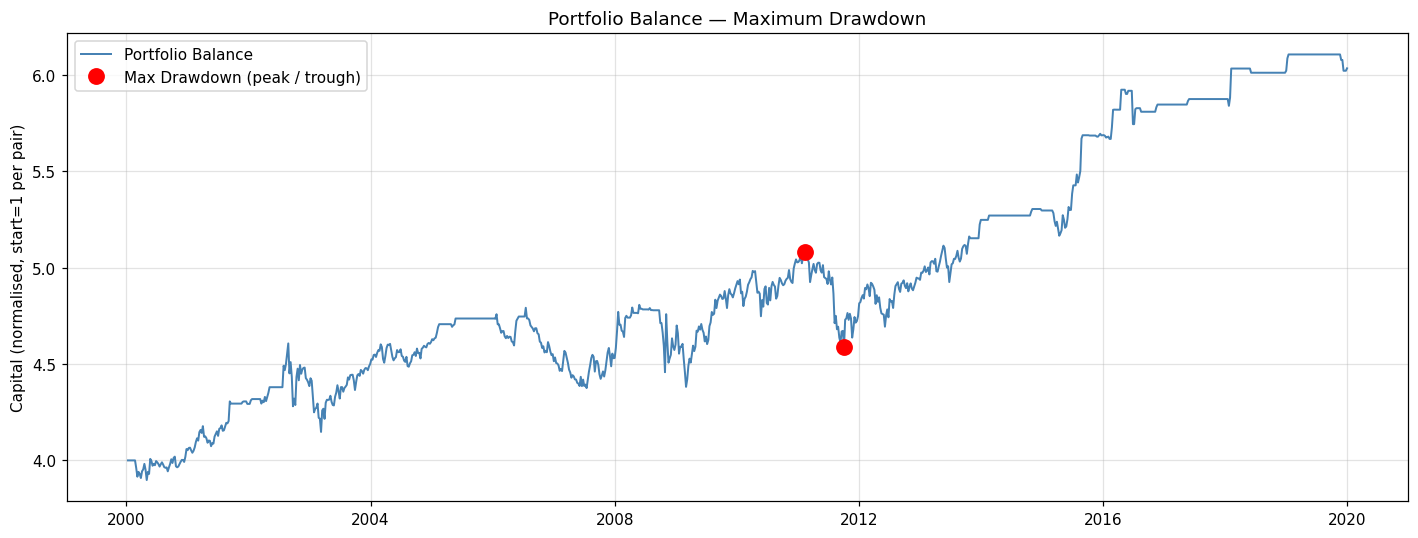

Max Drawdown    : -9.70%
Max DD Duration : 33 weeks
Max Drawdown (portfolio): -9.70%


,Leg1,Type1,Leg2,Type2,t_stat,p_value,zero_cross,half_life_wk,hurst,pos_trades,neg_trades,sharpe_w_costs,win_rate
0,EMUSTRUU,Bond Index,LMBITR,Bond Index,-3.6061,0.0056,59,25,0.5054,7,6,1.7345,53.846154
1,LG30TRUU,Bond Index,LP01TREU,Bond Index,-2.6078,0.0914,45,82,0.5077,5,7,1.1546,41.666667
2,LP01TREU,Bond Index,MXEU,Equity Index,-2.5761,0.0980,32,64,0.5493,26,12,0.4994,68.421053
3,LMBITR,Bond Index,LUACTRUU,Bond Index,-3.1064,0.0261,58,32,0.5351,6,5,0.3085,54.545455


In [16]:
results_train, pairs_summary_train = summarize_results(
    sharpe_train, cumret_train, perf_train, total_pairs, feature_types, N_YEARS_TRAIN
)
display(pairs_summary_train)

## 7. Test Period (Jan 2020 – Apr 2021) — Held-Out Evaluation (incl. COVID)

In [17]:
perf_test, sharpe_test, cumret_test = run_lstm_strategy(
    total_pairs, period_start=TEST_START, period_end=None, trained_models=trained_models
)

print('\n── TEST RESULTS ───────────────────────────────────────────────────────')
for i, pair in enumerate(total_pairs):
    print(f'  {pair[0]:12s} / {pair[1]:12s}  '
          f'Sharpe={sharpe_test[i]:.3f}  CumRet={cumret_test[i]:.2f}%')


── TEST RESULTS ───────────────────────────────────────────────────────
  LG30TRUU     / LP01TREU      Sharpe=3.018  CumRet=0.35%
  LP01TREU     / MXEU          Sharpe=4.010  CumRet=40.38%
  EMUSTRUU     / LMBITR        Sharpe=-0.425  CumRet=-0.70%
  LMBITR       / LUACTRUU      Sharpe=0.451  CumRet=0.90%


Average total ROI  : 10.23%
Average annual ROI : 7.60%
Pairs with positive returns: 75.0%
Portfolio Sharpe (annualised, rf=0, active wks): 2.596
Weekly return autocorrelation (lag-1): 0.102
Total trades : 14
Winning      : 9
Losing       : 5
Total drawdown periods : 19 weeks


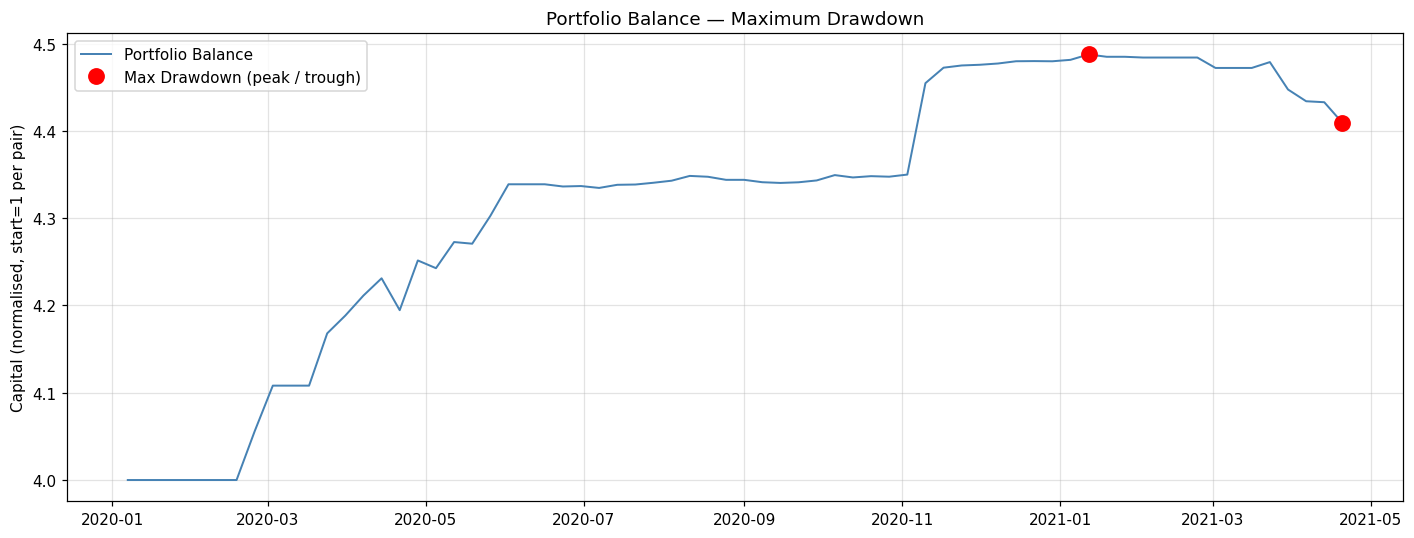

Max Drawdown    : -1.75%
Max DD Duration : 14 weeks
Max Drawdown (portfolio): -1.75%


,Leg1,Type1,Leg2,Type2,t_stat,p_value,zero_cross,half_life_wk,hurst,pos_trades,neg_trades,sharpe_w_costs,win_rate
0,LP01TREU,Bond Index,MXEU,Equity Index,-2.5761,0.0980,32,64,0.5493,4,2,4.0100,66.666667
1,LG30TRUU,Bond Index,LP01TREU,Bond Index,-2.6078,0.0914,45,82,0.5077,1,0,3.0185,100.000000
2,LMBITR,Bond Index,LUACTRUU,Bond Index,-3.1064,0.0261,58,32,0.5351,3,2,0.4515,60.000000
3,EMUSTRUU,Bond Index,LMBITR,Bond Index,-3.6061,0.0056,59,25,0.5054,1,1,-0.4250,50.000000


In [18]:
results_test, pairs_summary_test = summarize_results(
    sharpe_test, cumret_test, perf_test, total_pairs, feature_types, N_YEARS_TEST
)
display(pairs_summary_test)

## 8. Anomaly Signal Plots (Full Timeline)

Each pair: spread (top) + anomaly score (bottom).  
- Green / red shading → long / short position active  
- Light red → risk-off period (Y=1)  
- Dashed vertical → train/test boundary

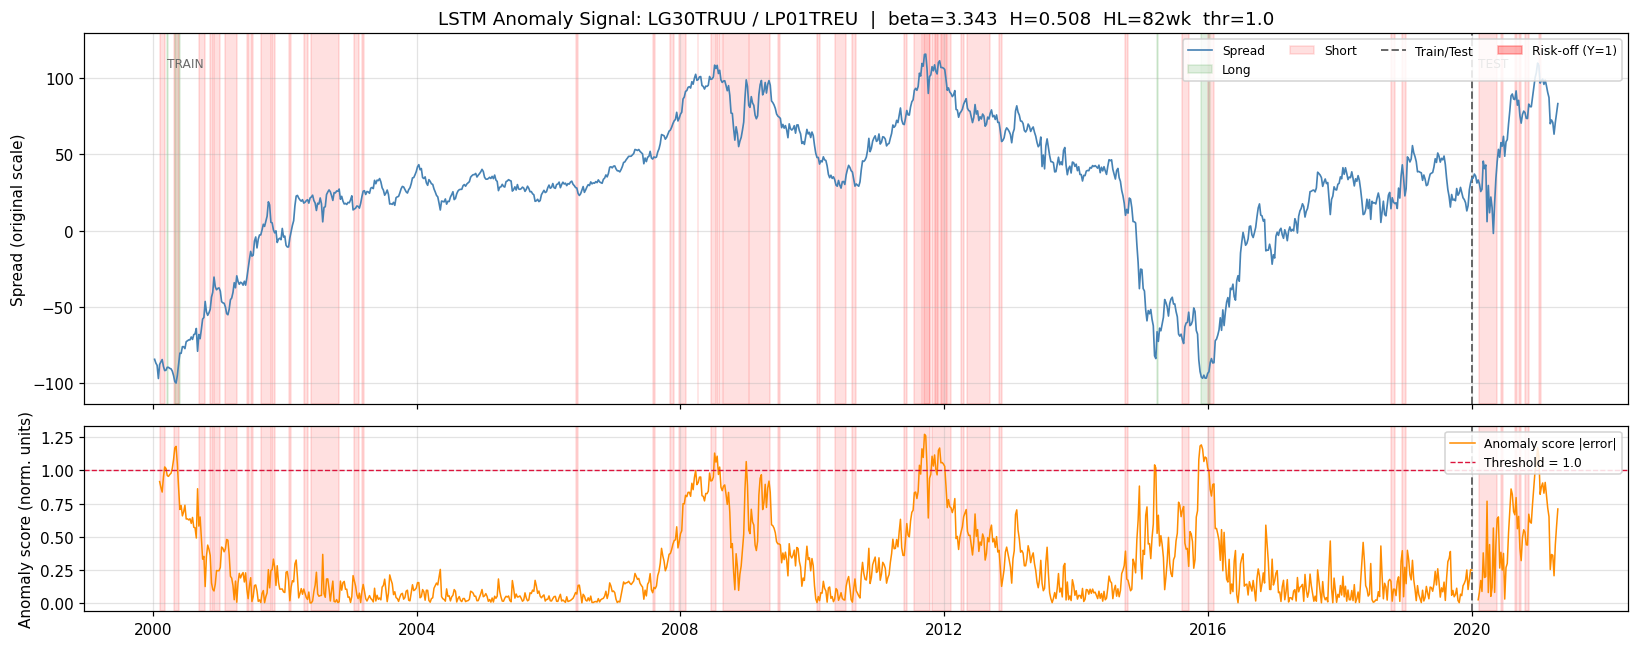

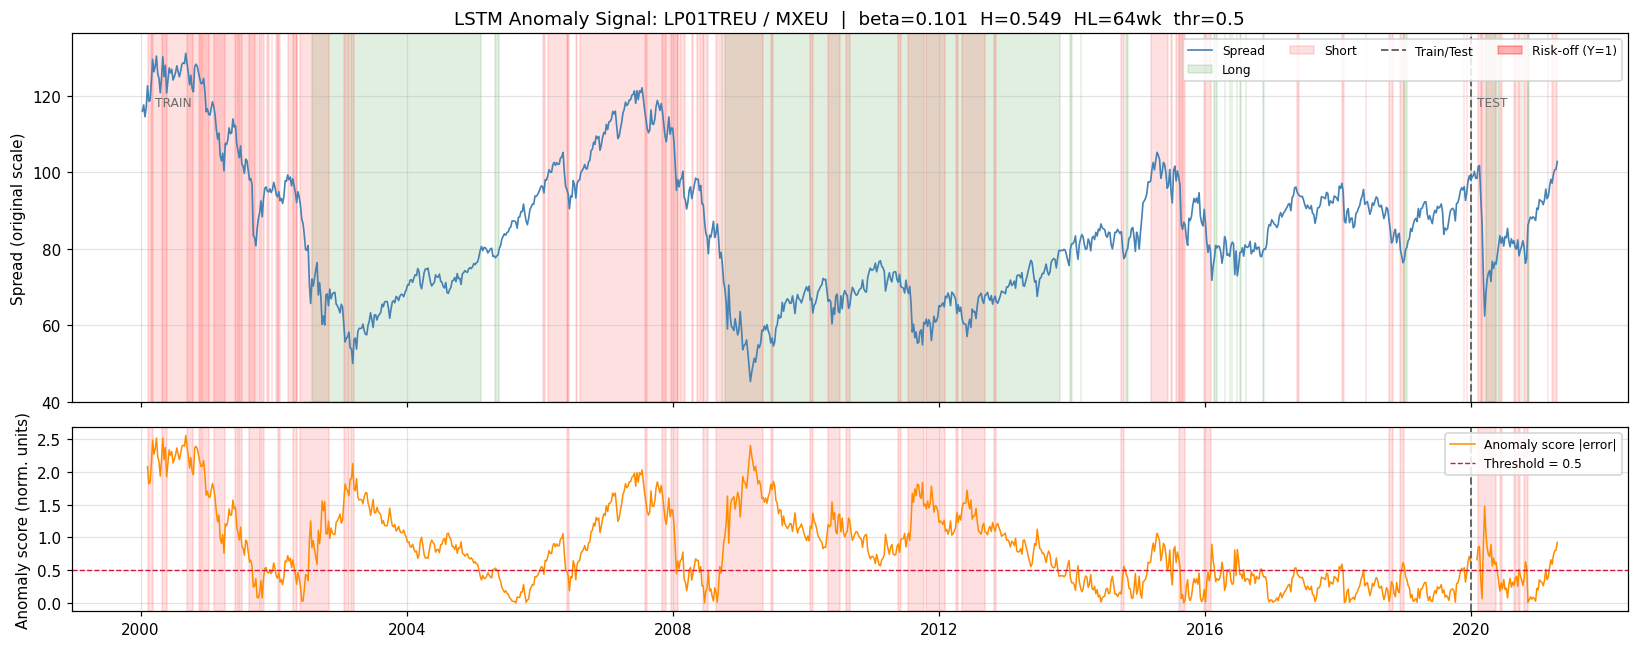

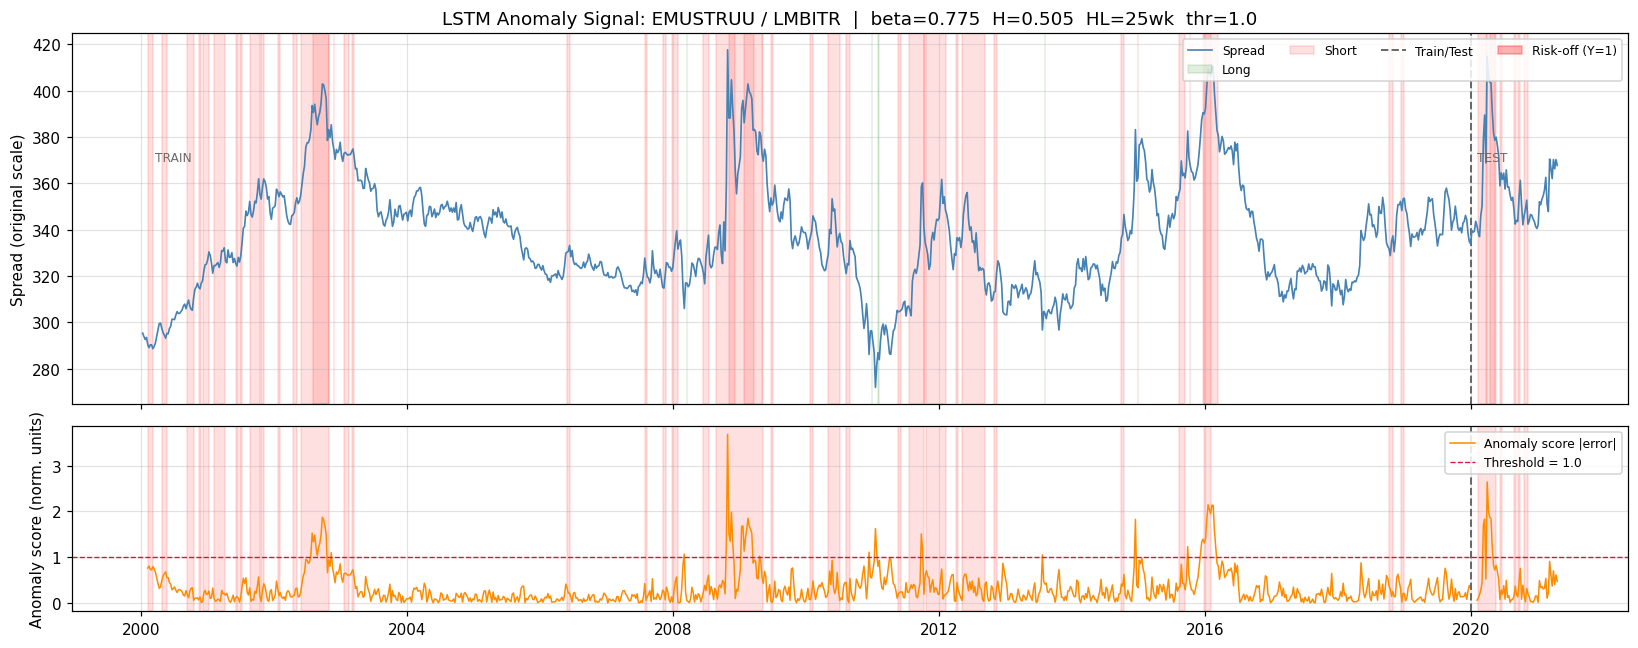

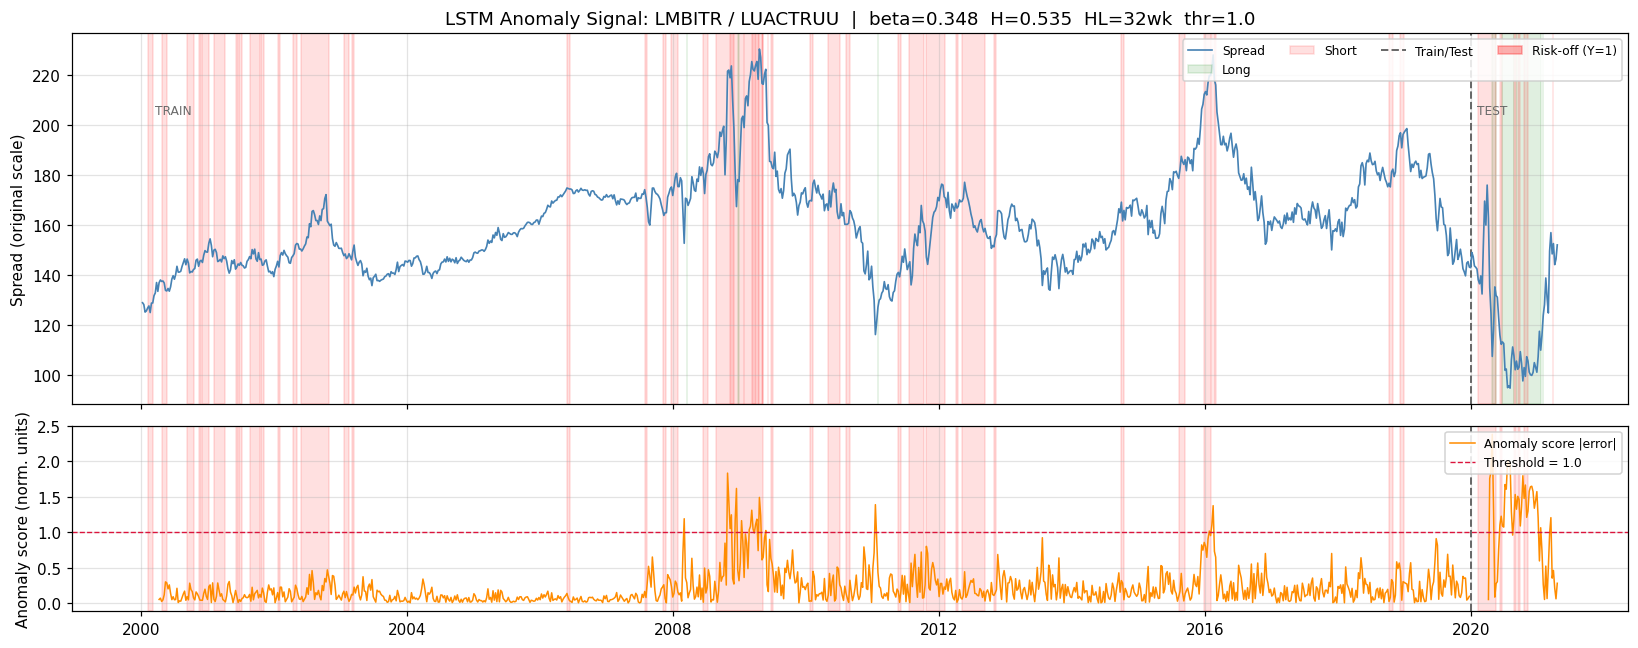

In [19]:
for i, (feat1, feat2, pair_info) in enumerate(total_pairs):
    beta        = pair_info['coint_coef']
    spread_full = pair_info['S2'] - beta * pair_info['S1']

    positions_full = pd.concat([
        perf_train[i][1]['position_during_day'],
        perf_test[i][1]['position_during_day'],
    ])

    score_train = perf_train[i][3]
    score_test  = perf_test[i][3]
    score_full  = pd.concat([score_train, score_test]).reindex(spread_full.index)

    thr = final_params[(feat1, feat2)]['threshold']
    title_suffix = (f'  |  beta={pair_info["coint_coef"]:.3f}  '
                    f'H={pair_info["hurst_exponent"]:.3f}  '
                    f'HL={pair_info["half_life"]}wk  thr={thr}')
    plot_pair_anomaly(feat1, feat2, spread_full, positions_full, score_full,
                      y_labels, thr=thr, title_suffix=title_suffix)

## 9. Equity Curves

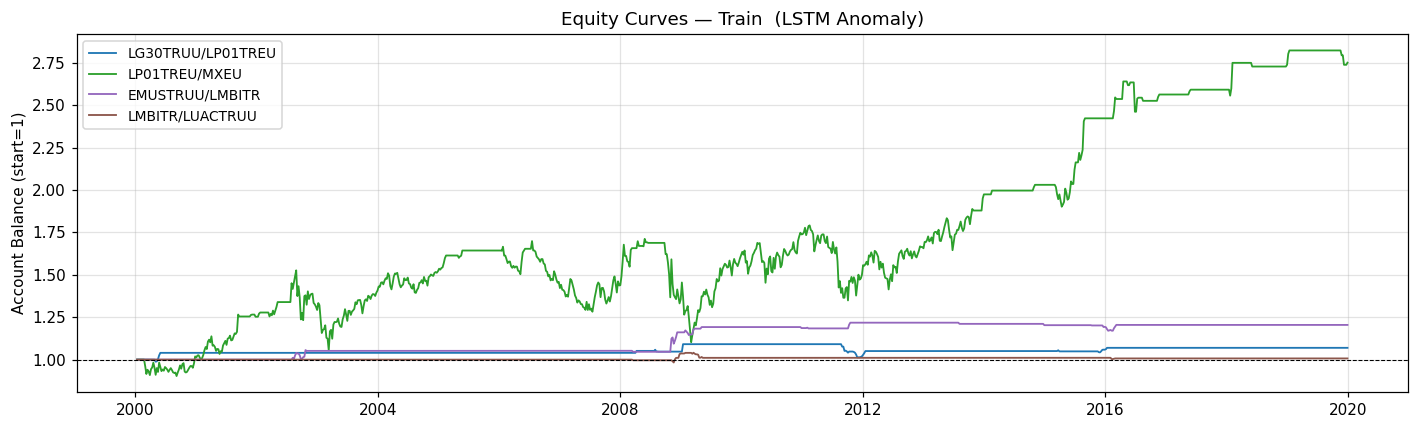

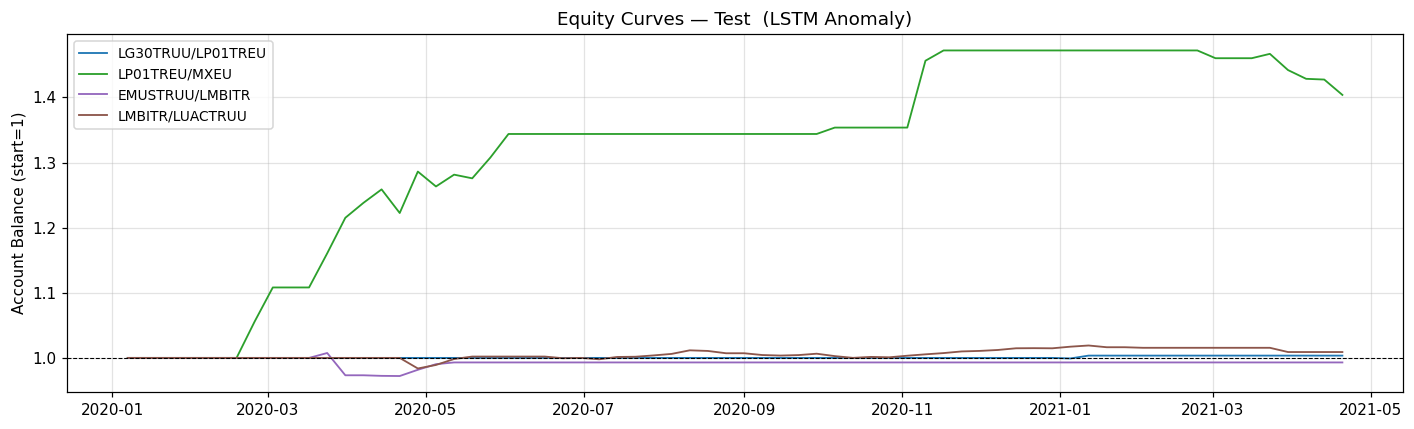

In [20]:
PERIOD_COLORS = ['#1f77b4', '#2ca02c', '#9467bd', '#8c564b']

for period_name, perf in [('Train', perf_train), ('Test', perf_test)]:
    fig, ax = plt.subplots(figsize=(13, 4))
    for i, (feat1, feat2, _) in enumerate(total_pairs):
        bal = perf[i][2]['account_balance']
        ax.plot(bal.index, bal, label=f'{feat1}/{feat2}',
                color=PERIOD_COLORS[i], linewidth=1.2)
    ax.axhline(1, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(f'Equity Curves — {period_name}  (LSTM Anomaly)')
    ax.set_ylabel('Account Balance (start=1)')
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## 10. Performance Summary

In [21]:
summary_table = pd.DataFrame({
    'Metric': [
        'Portfolio Sharpe (in-position)',
        'Avg Total ROI (%)',
        'Avg Annual ROI (%)',
        'Max Drawdown (%)',
        'Total Trades',
        'Winning Trades',
        'Losing Trades',
        '% Positive Pairs',
    ],
    'Train': [
        round(results_train['portfolio_sharpe'],  3),
        round(results_train['avg_total_roi'],      2),
        round(results_train['avg_annual_roi'],     2),
        round(results_train['max_drawdown'],       2),
        results_train['total_trades'],
        results_train['winning_trades'],
        results_train['losing_trades'],
        round(results_train['pct_positive_pairs'], 1),
    ],
    'Test': [
        round(results_test['portfolio_sharpe'],  3),
        round(results_test['avg_total_roi'],      2),
        round(results_test['avg_annual_roi'],     2),
        round(results_test['max_drawdown'],       2),
        results_test['total_trades'],
        results_test['winning_trades'],
        results_test['losing_trades'],
        round(results_test['pct_positive_pairs'], 1),
    ],
}).set_index('Metric')

display(summary_table)

,Train,Test
Metric,,
Portfolio Sharpe (in-position),0.563,2.596
Avg Total ROI (%),50.830,10.230
Avg Annual ROI (%),2.080,7.600
Max Drawdown (%),-9.700,-1.750
Total Trades,74.000,14.000
Winning Trades,44.000,9.000
Losing Trades,30.000,5.000
% Positive Pairs,100.000,75.000
